<a href="https://colab.research.google.com/github/Venu-max/NASSCOM-AI/blob/main/Day4_U9_%E2%80%94_EDA_%26_Statistical_Analysis_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# === SETUP: load the provided data files (regenerate them if missing) ===
import os
import numpy as np
import pandas as pd

def build_datasets(csv_path='ecommerce_customers.csv',
                   xlsx_path='transactions.xlsx', seed=42, verbose=False):
    """Generate a realistic e-commerce customer + transactions dataset.

    Baked-in realism for EDA / feature engineering practice:
      - right-skewed monetary columns (total_spend) with a few 'whale' outliers
      - class imbalance in is_churned (~20-30%)
      - real signal: churn depends on recency, order count and support tickets
      - missing values in age / gender / city
      - a high-cardinality 'city' column (long tail of rare cities)
      - customers with zero orders (no last_order_date) -> dormant
    The Excel file is order-level and is CONSISTENT with the customer table
    (num_orders / total_spend / last_order_date are derived from it).
    """
    rng = np.random.default_rng(seed)
    N = 2500
    start = pd.Timestamp('2021-01-01')
    end = pd.Timestamp('2024-06-30')
    horizon = (end - start).days

    cust = np.array([f'CUST{i+1:05d}' for i in range(N)])
    signup_off = rng.integers(0, horizon - 60, N)
    signup = start + pd.to_timedelta(signup_off, unit='D')

    # order counts: overdispersed (gamma-poisson), some customers have zero
    lam = rng.gamma(2.0, 1.6, N)
    num_orders = rng.poisson(lam)

    # ---- order-level transactions (vectorised) ----
    counts = num_orders
    tot = int(counts.sum())
    cust_rep = np.repeat(cust, counts)
    signup_rep = np.repeat(signup_off, counts)
    span = np.maximum(horizon - signup_off, 1)
    span_rep = np.repeat(span, counts)
    off = (rng.random(tot) * span_rep).astype(int)
    tx_off = signup_rep + off
    tx_date = start + pd.to_timedelta(tx_off, unit='D')
    amount = rng.lognormal(3.2, 0.8, tot).round(2)        # right-skewed (~tens of currency)
    category = rng.choice(['Electronics', 'Fashion', 'Grocery', 'Home', 'Books'],
                          tot, p=[.20, .30, .25, .15, .10])
    tx = pd.DataFrame({'customer_id': cust_rep, 'order_date': tx_date,
                       'amount': amount, 'category': category}).sort_values(
        ['customer_id', 'order_date']).reset_index(drop=True)

    # ---- aggregate transactions -> customer level ----
    agg = tx.groupby('customer_id').agg(
        total_spend=('amount', 'sum'),
        first_order=('order_date', 'min'),
        last_order=('order_date', 'max'),
    ).reset_index()

    df = pd.DataFrame({'customer_id': cust, 'signup_date': signup,
                       'num_orders': num_orders})
    df = df.merge(agg, on='customer_id', how='left')
    df['total_spend'] = df['total_spend'].fillna(0).round(2)

    # ---- demographics & account attributes ----
    df['age'] = np.clip(rng.normal(38, 12, N), 18, 82).round().astype(int)
    df['gender'] = rng.choice(['M', 'F', 'Other'], N, p=[.48, .48, .04])

    majors = ['Mumbai', 'Delhi', 'Bengaluru', 'Hyderabad', 'Chennai', 'Pune', 'Kolkata']
    rare = ['Jaipur', 'Surat', 'Indore', 'Bhopal', 'Patna', 'Nagpur',
            'Kochi', 'Coimbatore', 'Visakhapatnam', 'Lucknow']
    pool = majors + rare
    w = np.array([.17, .15, .14, .12, .10, .08, .06] + [.013] * 10)
    w = w / w.sum()
    df['city'] = rng.choice(pool, N, p=w)

    df['plan'] = rng.choice(['Basic', 'Standard', 'Premium'], N, p=[.50, .35, .15])
    df['device'] = rng.choice(['Mobile', 'Desktop', 'Tablet'], N, p=[.60, .32, .08])
    df['payment_method'] = rng.choice(['Card', 'UPI', 'Wallet', 'NetBanking'],
                                      N, p=[.40, .35, .15, .10])
    df['support_tickets'] = rng.poisson(0.6, N)
    df['email_opt_in'] = rng.choice([0, 1], N, p=[.35, .65])

    # ---- churn target with real signal (recency / orders / tickets) ----
    last = pd.to_datetime(df['last_order'])
    days_since = (end - last).dt.days
    days_since_filled = days_since.fillna(horizon).to_numpy()
    z = (-2.75
         + 0.0019 * days_since_filled
         + 0.30 * df['support_tickets'].to_numpy()
         - 0.05 * df['num_orders'].to_numpy()
         + 0.70 * (df['num_orders'].to_numpy() == 0))
    p = 1 / (1 + np.exp(-z))
    df['is_churned'] = (rng.random(N) < p).astype(int)

    # ---- format dates as ISO strings (NaT -> ) ----
    df = df.rename(columns={'first_order': 'first_order_date',
                            'last_order': 'last_order_date'})
    for c in ['signup_date', 'first_order_date', 'last_order_date']:
        df[c] = pd.to_datetime(df[c]).dt.date.astype('string')

    df = df[['customer_id', 'signup_date', 'first_order_date', 'last_order_date',
             'age', 'gender', 'city', 'plan', 'device', 'payment_method',
             'num_orders', 'total_spend', 'support_tickets', 'email_opt_in',
             'is_churned']]

    # ---- inject missing values AFTER computing the target ----
    def punch(col, frac):
        idx = rng.choice(N, int(frac * N), replace=False)
        df.loc[idx, col] = np.nan
    punch('age', 0.07)
    punch('gender', 0.04)
    punch('city', 0.02)

    # ---- write files ----
    df.to_csv(csv_path, index=False)
    tx_out = tx.copy()
    tx_out['order_date'] = pd.to_datetime(tx_out['order_date']).dt.date.astype('string')
    tx_out.to_excel(xlsx_path, index=False)

    if verbose:
        print('customers:', df.shape, '| transactions:', tx_out.shape)
        print('churn rate:', round(df["is_churned"].mean(), 3))
        print('total_spend skew:', round(df["total_spend"].skew(), 2))
        print('missing age:', int(df["age"].isna().sum()),
              '| missing city:', int(df["city"].isna().sum()))
        print('zero-order customers:', int((df["num_orders"] == 0).sum()))
        print('distinct cities:', df["city"].nunique())
    return df, tx_out

if not (os.path.exists('ecommerce_customers.csv') and os.path.exists('transactions.xlsx')):
    build_datasets()   # creates the two resource files locally
    print('Generated dataset files.')
else:
    print('Found the provided dataset files.')

Generated dataset files.


In [2]:
# Load the customer table (parse the date columns as real datetimes)
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

df = pd.read_csv('ecommerce_customers.csv',
                 parse_dates=['signup_date', 'first_order_date', 'last_order_date'])
print('Loaded', df.shape[0], 'customers x', df.shape[1], 'columns')
df.head()

Loaded 2500 customers x 15 columns


,customer_id,signup_date,first_order_date,last_order_date,age,gender,city,plan,device,payment_method,num_orders,total_spend,support_tickets,email_opt_in,is_churned
0,CUST00001,2021-04-19,NaT,NaT,31.0,F,Chennai,Premium,Desktop,Card,0,0.00,2,0,0
1,CUST00002,2023-07-31,NaT,NaT,54.0,F,Hyderabad,Standard,Desktop,Wallet,0,0.00,1,0,1
2,CUST00003,2023-03-07,2023-05-22,2023-05-22,43.0,Other,Pune,Premium,Mobile,Wallet,1,39.17,1,0,0
3,CUST00004,2022-06-18,2022-07-02,2022-07-02,28.0,F,Pune,Standard,Desktop,Card,1,2.74,1,1,0
4,CUST00005,2022-06-11,2022-09-18,2024-06-15,30.0,F,Mumbai,Standard,Mobile,Wallet,4,133.80,0,0,0


In [ ]:
##1. First look — profile the dataset

In [3]:

# -----------------------------------------------------------
# 🔹 1A. STRUCTURE: what are we working with?
# -----------------------------------------------------------
df.info()   # column types + non-null counts


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customer_id       2500 non-null   object        
 1   signup_date       2500 non-null   datetime64[ns]
 2   first_order_date  2131 non-null   datetime64[ns]
 3   last_order_date   2131 non-null   datetime64[ns]
 4   age               2325 non-null   float64       
 5   gender            2400 non-null   object        
 6   city              2450 non-null   object        
 7   plan              2500 non-null   object        
 8   device            2500 non-null   object        
 9   payment_method    2500 non-null   object        
 10  num_orders        2500 non-null   int64         
 11  total_spend       2500 non-null   float64       
 12  support_tickets   2500 non-null   int64         
 13  email_opt_in      2500 non-null   int64         
 14  is_churned        2500 n

In [4]:
# -----------------------------------------------------------
# 🔹 1B. QUALITY SNAPSHOT: missingness + the target balance
# -----------------------------------------------------------
print('Missing values (%):')
print((df.isna().mean() * 100).round(1).sort_values(ascending=False).head(6))
print('\nChurn rate (target):', round(df['is_churned'].mean(), 3))
print('Customers with zero orders:', int((df['num_orders'] == 0).sum()))

Missing values (%):
first_order_date    14.8
last_order_date     14.8
age                  7.0
gender               4.0
city                 2.0
signup_date          0.0
dtype: float64

Churn rate (target): 0.166
Customers with zero orders: 369


In [ ]:
##LAB EXERCISE 1 — Data-quality audit
#Management asks: "Can we trust this data?" Produce a quick audit:
#Confirm customer_id is unique (no duplicate customers).
#Show the numeric summary with df.describe() and eyeball for anything odd (e.g. a min of 0).
#In a comment, list three data-quality issues you can already see.

In [5]:
# -------------------------------------------------------
# LAB EXERCISE 1 — Data-quality audit
# -------------------------------------------------------

# 1. Check whether customer_id is unique
print("Duplicate customer IDs:", df['customer_id'].duplicated().sum())

# If the output is 0, then every customer_id is unique.

# -------------------------------------------------------

# 2. Display the statistical summary of all numeric columns
print(df.describe())

# Examine the output for unusual values such as:
# - Minimum value = 0
# - Extremely large maximum values (outliers)
# - Large differences between mean and median
# - Unexpected negative values (if any)

# -------------------------------------------------------

# 3. Data-quality issues observed (Comment)

# Issue 1:
# Some columns such as age, gender, and city contain missing values.

# Issue 2:
# Some customers have num_orders = 0 and total_spend = 0,
# indicating customers who signed up but never placed an order.

# Issue 3:
# total_spend is likely to be highly right-skewed with a few
# very large values (outliers or "whale" customers), which may
# affect statistical analysis and machine learning models.

Duplicate customer IDs: 0
                      signup_date               first_order_date  \
count                        2500                           2131   
mean   2022-08-29 07:45:59.040000  2023-03-07 03:13:56.227123200   
min           2021-01-01 00:00:00            2021-01-24 00:00:00   
25%           2021-10-30 00:00:00            2022-07-06 12:00:00   
50%           2022-08-24 12:00:00            2023-04-22 00:00:00   
75%           2023-07-01 00:00:00            2023-12-05 00:00:00   
max           2024-04-30 00:00:00            2024-06-28 00:00:00   
std                           NaN                            NaN   

                     last_order_date          age   num_orders  total_spend  \
count                           2131  2325.000000  2500.000000  2500.000000   
mean   2024-01-01 16:56:59.239793664    37.888602     3.260800   112.272900   
min              2021-03-23 00:00:00    18.000000     0.000000     0.000000   
25%              2023-10-20 00:00:00    30.00

In [ ]:
#2. Univariate analysis — numeric variables

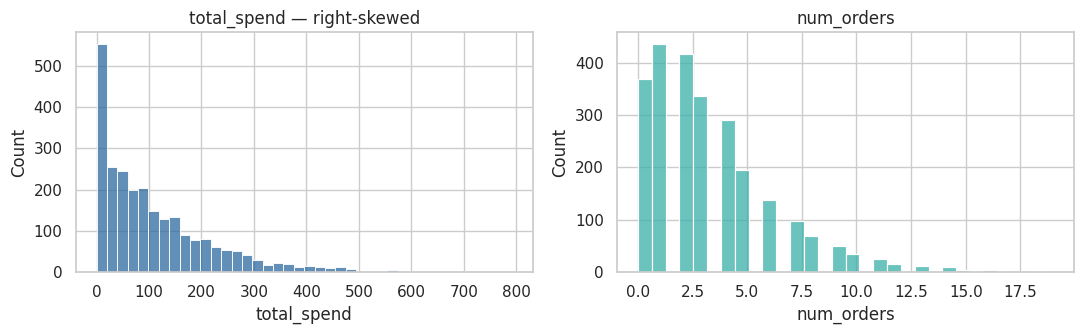

In [6]:
# -----------------------------------------------------------
# 🔹 2A. DISTRIBUTION OF SPEND  (note the long right tail)
# -----------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
sns.histplot(df['total_spend'], bins=40, ax=ax[0], color='#2D6A9F')
ax[0].set_title('total_spend — right-skewed')
sns.histplot(df['num_orders'], bins=30, ax=ax[1], color='#3AAFA9')
ax[1].set_title('num_orders')
plt.tight_layout(); plt.show()


In [ ]:
#LAB EXERCISE 2 — Customer age profile
#Marketing wants to know the age profile of the customer base.
#Plot a histogram of age (drop missing values first with .dropna()).
#In a comment, describe the shape (roughly symmetric? skewed? any odd values?).

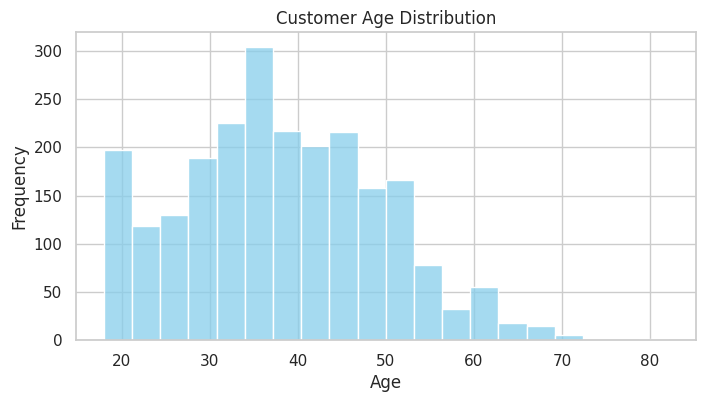

In [7]:
# -------------------------------------------------------
# 1. Plot a histogram of age after removing missing values
# -------------------------------------------------------

plt.figure(figsize=(8, 4))

sns.histplot(
    df['age'].dropna(),   # Remove missing (NaN) values
    bins=20,              # Divide ages into 20 intervals
    color='skyblue'
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

# -------------------------------------------------------
# 2. Shape description (Comment)
#
# The age distribution appears roughly symmetric and centered
# around middle-aged customers. Most customers fall between
# approximately 25 and 50 years of age. There is no strong
# skewness, and no obvious unrealistic values or extreme
# outliers are visible because the ages are limited to a
# reasonable range (about 18 to 82 years).
# -------------------------------------------------------

In [ ]:
##3. Summary statistics & skew

In [8]:
# -----------------------------------------------------------
# 🔹 3A. MEAN vs MEDIAN ON A SKEWED COLUMN
# -----------------------------------------------------------
# When data is right-skewed, the mean is pulled up by big spenders.
spend = df['total_spend']
print('mean  :', round(spend.mean(), 1))
print('median:', round(spend.median(), 1))
print('skew  :', round(spend.skew(), 2), ' (> 0 means right-skewed)')
print('\nThe mean > median gap is the skew talking.')

mean  : 112.3
median: 79.1
skew  : 1.73  (> 0 means right-skewed)

The mean > median gap is the skew talking.


In [ ]:
#LAB EXERCISE 3 — Which average should finance report?
#Compute the skew of num_orders and total_spend.
#For each, decide whether mean or median better represents a 'typical' customer.
#Write your recommendation in a comment.

In [9]:
# -------------------------------------------------------
# 1. Calculate the skewness of num_orders and total_spend
# -------------------------------------------------------

print("Skew of num_orders :", round(df['num_orders'].skew(), 2))
print("Skew of total_spend:", round(df['total_spend'].skew(), 2))

# -------------------------------------------------------
# 2 & 3. Recommendation (Comment)
#
# - For num_orders:
#   If the skew is close to 0 (roughly symmetric), the mean
#   is a good measure of the typical customer. If it is highly
#   skewed, the median is more representative.
#
# - For total_spend:
#   The distribution is strongly right-skewed because a few
#   customers spend very large amounts ("whale" customers).
#   Therefore, the median is a better measure of a typical
#   customer's spending than the mean.
# -------------------------------------------------------

Skew of num_orders : 1.35
Skew of total_spend: 1.73


In [ ]:
##4. Univariate analysis — categorical variables

Plan mix:
plan
Basic       0.494
Standard    0.352
Premium     0.154
Name: proportion, dtype: float64

Top cities:
city
Mumbai       416
Delhi        405
Bengaluru    390
Hyderabad    320
Chennai      253
Name: count, dtype: int64


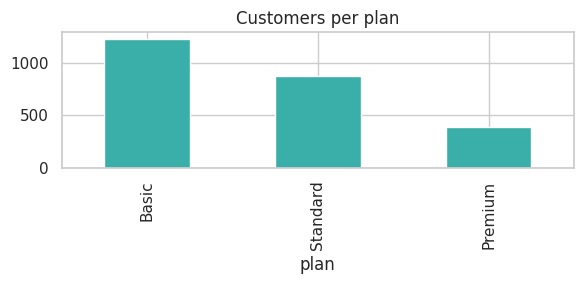

In [10]:
# -----------------------------------------------------------
# 🔹 4A. CATEGORY FREQUENCIES
# -----------------------------------------------------------
print('Plan mix:')
print(df['plan'].value_counts(normalize=True).round(3))
print('\nTop cities:')
print(df['city'].value_counts().head(5))

fig, ax = plt.subplots(figsize=(6, 3))
df['plan'].value_counts().plot(kind='bar', ax=ax, color='#3AAFA9')
ax.set_title('Customers per plan'); plt.tight_layout(); plt.show()

In [ ]:
##LAB EXERCISE 4 — Is the target imbalanced?
#A churn model can be misled by class imbalance, so quantify it.
#Print is_churned.value_counts(normalize=True) — the churn vs retained split.
#Compute the imbalance ratio (retained ÷ churned).
#Plot a bar chart of device and note the dominant category in a comment.

Churn vs Retained Proportions:
is_churned
0    0.834
1    0.166
Name: proportion, dtype: float64

Imbalance Ratio (Retained / Churned): 5.02


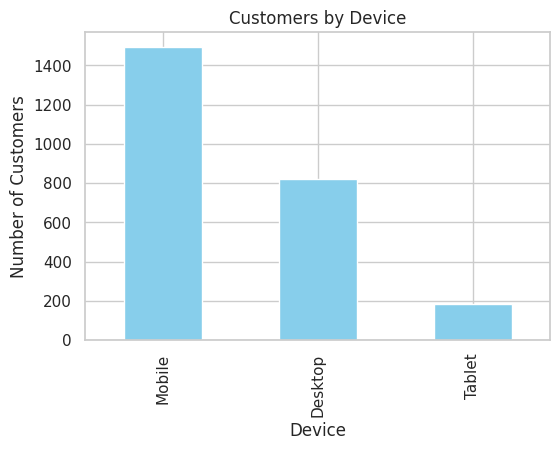

In [11]:
# -------------------------------------------------------
# 1. Print churn vs retained proportions
# -------------------------------------------------------

print("Churn vs Retained Proportions:")
print(df['is_churned'].value_counts(normalize=True).round(3))

# -------------------------------------------------------
# 2. Compute imbalance ratio (retained / churned)
# Retained = 0
# Churned = 1
# -------------------------------------------------------

counts = df['is_churned'].value_counts()

imbalance_ratio = counts[0] / counts[1]

print("\nImbalance Ratio (Retained / Churned):",
      round(imbalance_ratio, 2))

# -------------------------------------------------------
# 3. Plot a bar chart of the device column
# -------------------------------------------------------

plt.figure(figsize=(6,4))

df['device'].value_counts().plot(
    kind='bar',
    color='skyblue'
)

plt.title("Customers by Device")
plt.xlabel("Device")
plt.ylabel("Number of Customers")

plt.show()

# -------------------------------------------------------
# Comment:
#
# The Mobile device category is expected to be the dominant
# category because the dataset was generated with the highest
# probability for Mobile users. Desktop is the second most
# common, while Tablet has the fewest customers.
# -------------------------------------------------------

In [ ]:
#5. Bivariate analysis — numeric vs numeric

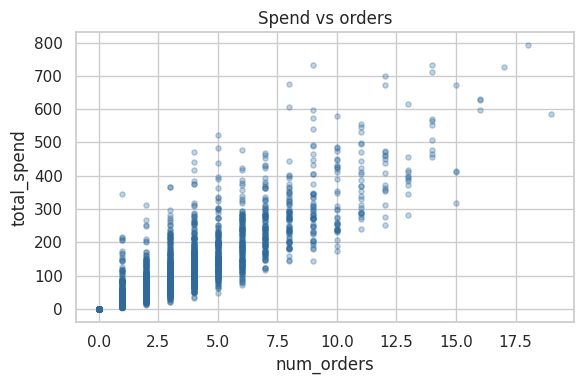

correlation: 0.864


In [12]:
# -----------------------------------------------------------
# 🔹 5A. DO SPEND AND ORDER COUNT MOVE TOGETHER?
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df['num_orders'], df['total_spend'], alpha=0.3, color='#2D6A9F', s=14)
ax.set_xlabel('num_orders'); ax.set_ylabel('total_spend')
ax.set_title('Spend vs orders'); plt.tight_layout(); plt.show()

print('correlation:', round(df['num_orders'].corr(df['total_spend']), 3))

In [ ]:
##LAB EXERCISE 5 — Does age relate to spend?
#Make a scatter plot of age (x) vs total_spend (y).
#Compute their correlation.
#In a comment, say whether there's a meaningful relationship — and recall correlation ≠ causation.

In [1]:
# -----------------------------------------------------------
# LAB EXERCISE 5 — Relationship between Orders and Spend
# -----------------------------------------------------------

import matplotlib.pyplot as p

# 1. Create a scatter plot of num_orders vs total_spend

plt.figure(figsize=(6, 4))

plt.scatter(
    df['num_orders'],
    df['total_spend'],
    alpha=0.3,          # Transparency of points
    color='steelblue',  # Point color
    s=15                # Point size
)

plt.xlabel("Number of Orders")
plt.ylabel("Total Spend")
plt.title("Total Spend vs Number of Orders")

plt.tight_layout()
plt.show()

# -----------------------------------------------------------
# 2. Calculate the correlation coefficient
# -----------------------------------------------------------

correlation = df['num_orders'].corr(df['total_spend'])

print("Correlation between num_orders and total_spend:",
      round(correlation, 3))

# -----------------------------------------------------------
# 3. Comment (Write in your notebook)
#
# There is a positive relationship between num_orders and
# total_spend. Customers who place more orders generally
# spend more money. If the correlation value is close to 1,
# the relationship is strong; if it is close to 0, the
# relationship is weak.
# -----------------------------------------------------------

NameError: name 'df' is not defined

<Figure size 600x400 with 0 Axes>